In [1]:
import os
import platform
import pandas as pd
import numpy as np
import torch
import pytorch_lightning as pl
import seaborn as sns
import matplotlib.pyplot as plt

from pytorch_lightning.callbacks.early_stopping import EarlyStopping
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from multiprocessing import cpu_count

from model.proposed_algbra import MYModule
# from model.dkt import DKTModule
# from model.sakt import SAKTModule
# from model.dkvmn import DKVMNModule

### 可复现性

In [2]:
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
pl.seed_everything(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Global seed set to 42


### hyperparameter tuning

In [3]:
# SEQ_LEN = 200
# BATCH_SIZE = 64
# EMBED_DIM = 128
# DROP_OUT = 0.9
# NUM_WORKERS = 0 if platform.system() == 'Windows' else cpu_count()
# N_GCN_LAYERS = 0
# print("os:{}, num-workers:{}".format(platform.system(), NUM_WORKERS))

结果：0.84622

In [4]:
SEQ_LEN = 1317
# SEQ_LEN = 200
BATCH_SIZE = 16
EMBED_DIM = 128
DROP_OUT = 0.8
NUM_WORKERS = 0 if platform.system() == 'Windows' else cpu_count()
N_GCN_LAYERS = 0
# N_GCN_LAYERS = 2
print("os:{}, num-workers:{}".format(platform.system(), NUM_WORKERS))

os:Linux, num-workers:16


结果：0.847

### load and process assist data

In [5]:
dataset_name = 'algebra_2006_2007'
dataset_path = os.path.join(os.getcwd(), 'dataset', dataset_name)

df = pd.read_csv(os.path.join(dataset_path, "processed_data.csv"), low_memory=False, encoding="ISO-8859-1")
df.columns = ['user_id', 'q_type', 'q_idx', 's_idx', 'ms_first_response', 'correct', 'q_diff']
df = df.sort_values(by='user_id')

key_user, key_q, key_s, key_qtype, key_diff, key_elpsed, key_correct = 'user_id', 'q_idx', 's_idx', 'q_type', 'q_diff', 'ms_first_response', 'correct'

sacler = MinMaxScaler()
tmp = sacler.fit_transform(df[[key_elpsed]])
df[[key_elpsed]] = tmp



### algbra interaction

In [6]:
df

,user_id,q_type,q_idx,s_idx,ms_first_response,correct,q_diff
71170,0I891Gg,100,2864,329,0.001247,1,0.916667
68205,0I891Gg,18,323,1,0.000779,1,0.735391
68204,0I891Gg,18,323,4,0.026185,0,0.735391
68203,0I891Gg,18,323,3,0.000935,1,0.735391
68202,0I891Gg,18,323,0,0.000935,1,0.735391
...,...,...,...,...,...,...,...
184996,zt5vuLM,123,10284,481,0.002494,1,0.986486
184997,zt5vuLM,123,10284,482,0.000935,1,0.986486
184998,zt5vuLM,123,10284,485,0.001247,1,0.986486
185000,zt5vuLM,124,5924,487,0.054551,1,0.837209


In [7]:
problems = df[key_q].unique() # 获取去重的问题序列
skills = df[key_s].unique()

# 多知识点设为新的知识点
# file = open(os.path.join(dataset_path, 'edge_list.dat'), 'w')
# file.write("{}\t{}\t{}\n".format('qid', 'sid', 'weight'))
# for qid in tqdm(range(len(problems))): 
#     tmp_df = df[df[key_q] == qid]
#     # 既然一个问题多个知识点，那就摆烂吧
#     for s in tmp_df[key_s].unique():
#         # build problem-skill bipartite
#         file.write("{}\t{}\t{}\n".format(qid, s, 1))
# file.close()


N_QUESTION = len(problems)
N_SKILL = len(skills)
N_QUESTION_TYPE = len(df[key_qtype].unique())



print("num of question:{}, num of skill:{}, n_question_type:{}".format(N_QUESTION, N_SKILL, N_QUESTION_TYPE))


num of question:91759, num of skill:1703, n_question_type:153


In [8]:
df.head()

,user_id,q_type,q_idx,s_idx,ms_first_response,correct,q_diff
71170,0I891Gg,100,2864,329,0.001247,1,0.916667
68205,0I891Gg,18,323,1,0.000779,1,0.735391
68204,0I891Gg,18,323,4,0.026185,0,0.735391
68203,0I891Gg,18,323,3,0.000935,1,0.735391
68202,0I891Gg,18,323,0,0.000935,1,0.735391


In [9]:
# 我们需要将数据进行预处理，每个学生的学习记录利用group by合并为序列。
def generate_group_by_df(df):
    # KEY = key_s if Q_IS_S else key_q
    group = df.groupby(['user_id']).apply(lambda r: (
            r[key_q].values,
            # r[KEY].values,
            r[key_s].values,
            r[key_qtype].values,
            r[key_diff].values,
            r[key_elpsed].values,
            r[key_correct].values,
            ))
    return group

# group = generate_group_by_df(df)

df_train, df_test = pd.read_csv(os.path.join(dataset_path, "train.csv"), low_memory=False, encoding="ISO-8859-1"), pd.read_csv(os.path.join(dataset_path, "test.csv"), low_memory=False, encoding="ISO-8859-1")
train, val = generate_group_by_df(df_train), generate_group_by_df(df_test)

N_QUERY_FEATURES = len(train.iloc[0])-1
print("N_QUERY_FEATURES:{}".format(N_QUERY_FEATURES))

N_QUERY_FEATURES:5


In [10]:
len_list = [len(train.iloc[i][0]) for i in range(len(train))]
print(np.mean(len_list))

1316.9279026217228


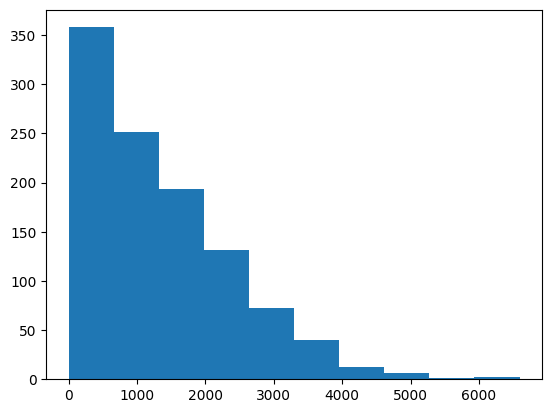

In [11]:
import matplotlib.pyplot as plt
plt.hist(len_list)
plt.show()

###  algebra dataset

In [12]:
from data_loader.algebra import AlgebraDataset


train_dataset = AlgebraDataset(train, N_QUESTION, SEQ_LEN)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)

val_dataset = AlgebraDataset(val, N_QUESTION, SEQ_LEN)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print("train:{}, test:{}".format(len(train_dataset), len(val_dataset)))


## todo for saint in algebra dataset
# from data_loader.saintdataset import SAINTDataset

# N_Q_OR_S = N_SKILL if Q_IS_S else N_QUESTION


# train_dataset = SAINTDataset(train, N_Q_OR_S, SEQ_LEN)
# train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)

# val_dataset = SAINTDataset(val, N_Q_OR_S, SEQ_LEN)
# val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# print("train:{}, test:{}".format(len(train_dataset), len(val_dataset)))

train:1068, test:268


In [13]:
# val_dataset[5][2]

### load birepart data

In [14]:
from utils.bipartited_data import load_bipartitedata
df_edge = pd.read_table(os.path.join(dataset_path, 'edge_list.dat'), sep='\t')
gcn_data, q_rev_dict, s_rev_dict, q_dict, s_dict = load_bipartitedata(df_edge)
gcn_data = gcn_data.to("cuda")

In [15]:
df_edge = pd.read_table(os.path.join(dataset_path, 'edge_list.dat'), sep='\t')
len(df_edge['sid'].unique())

1703

In [16]:
len(q_dict)

91759

In [17]:
# from model.proposed_algbra import MYModule

# import warnings
# warnings.filterwarnings('ignore')

# # TODO 测试一下属性特征
# N_QUERY_FEATURES = 5

# model = MYModule(
#     n_question=N_QUESTION,
#     n_skill=N_SKILL,
#     n_qtype=N_QUESTION_TYPE,
#     max_seq=SEQ_LEN,
#     embed_dim=EMBED_DIM,
#     n_query_features=N_QUERY_FEATURES,
#     n_gcn_layers=N_GCN_LAYERS,
#     gcn_data=gcn_data,
#     dropout=DROP_OUT,
#     new_att=False
# )
# print(model)

In [18]:
from model.brikt26_no_ca import MYModule

import warnings
warnings.filterwarnings('ignore')

# TODO 测试一下属性特征
N_QUERY_FEATURES = 5

model = MYModule(
    n_question=N_QUESTION,
    n_skill=N_SKILL,
    n_qtype=N_QUESTION_TYPE,
    max_seq=SEQ_LEN,
    embed_dim=EMBED_DIM,
    n_query_features=N_QUERY_FEATURES,
    n_gcn_layers=N_GCN_LAYERS,
    gcn_data=gcn_data,
    dropout=DROP_OUT,
    new_att=True
)
print(model)

91759 1703 153 1317 128 5 BipartiteData(edge_index_q2s=[2, 404814], edge_index_s2q=[2, 404814], num_q=91759, num_s=1703)
MYModule(
  (loss): BCEWithLogitsLoss()
  (model): MYMODEL(
    (embedding): Embedding(183519, 128)
    (qt_embedding): Embedding(153, 128)
    (diff_embedding): Linear(in_features=1, out_features=128, bias=True)
    (ms_first_response_embedding): Linear(in_features=1, out_features=128, bias=True)
    (combine_q_embedding_q): Linear(in_features=512, out_features=128, bias=True)
    (q_feature_layer_norm_q): LayerNorm((1316, 128), eps=1e-05, elementwise_affine=True)
    (combine_q_embedding_x): Linear(in_features=256, out_features=128, bias=True)
    (q_feature_layer_norm_x): LayerNorm((1316, 128), eps=1e-05, elementwise_affine=True)
    (gcn): LightGCNStack(
      (convs): ModuleList()
      (embed_q): Embedding(91759, 128)
      (embed_s): Embedding(1703, 128)
    )
    (multi_att): MultiHeadAttentionLayer(
      (relative_position_k): RelativePosition()
      (rela

In [19]:
# from model.brikt26_no_SI_algebra import MYModule

# import warnings
# warnings.filterwarnings('ignore')

# # TODO 测试一下属性特征
# N_QUERY_FEATURES = 2

# model = MYModule(
#     n_question=N_QUESTION,
#     n_skill=N_SKILL,
#     n_qtype=N_QUESTION_TYPE,
#     max_seq=SEQ_LEN,
#     embed_dim=EMBED_DIM,
#     n_query_features=N_QUERY_FEATURES,
#     n_gcn_layers=N_GCN_LAYERS,
#     gcn_data=gcn_data,
#     dropout=DROP_OUT,
#     new_att=True
# )
# print(model)

In [20]:
checkpoint_callback = pl.callbacks.ModelCheckpoint(save_top_k=1, verbose=True, monitor='v_auc', mode='max')

In [21]:
patience = 6 if N_QUERY_FEATURES == 6 else 3

In [22]:
trainer = pl.Trainer(
    gpus=1, 
    max_epochs=200, 
    auto_lr_find=True, 
    callbacks=[checkpoint_callback, EarlyStopping(monitor="v_auc", mode="max", patience=6)]
)
print("patience:{}".format(patience))

GPU available: True, used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


patience:3


In [23]:
trainer.fit(model=model, train_dataloaders=train_dataloader,val_dataloaders=val_dataloader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type              | Params
--------------------------------------------
0 | loss  | BCEWithLogitsLoss | 0     
1 | model | MYMODEL           | 36.3 M
--------------------------------------------
36.3 M    Trainable params
0         Non-trainable params
36.3 M    Total params
145.383   Total estimated model params size (MB)


Sanity Checking: 0it [00:00, ?it/s]

Training: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Epoch 0, global step 67: 'v_auc' reached 0.77135 (best 0.77135), saving model to '/home/czy/KT/BRIKT/lightning_logs/version_157/checkpoints/epoch=0-step=67.ckpt' as top 1


...

Epoch 15, global step 1072: 'v_auc' was not in top 1


Validation: 0it [00:00, ?it/s]

Epoch 16, global step 1139: 'v_auc' was not in top 1


Validation: 0it [00:00, ?it/s]

Epoch 17, global step 1206: 'v_auc' was not in top 1
